In [93]:
import pandas as pd

# Load the dataset
file_path = "../data/taoism_comments_labeled_with_sentiment_emotion.csv"
comments_df = pd.read_csv(file_path)

# Show structure of the dataset
print(comments_df.columns)

# Optional: preview the dataset
comments_df.head()
pd.set_option('display.max_colwidth', None)

Index(['post_id', 'comment_id', 'parent_id', 'author', 'body', 'score',
       'created_utc', 'depth', 'clean_text', 'cluster', 'topic_label',
       'rhetoric', 'sentiment_label', 'sentiment_score', 'emotion_labels',
       'top_emotion'],
      dtype='object')


In [99]:
comments_df["topic_label"].head(20)

0              Taoist Philosophical Reflections
1              Philosophical Taoist Reflections
2             Taoism Misinterpretation Concerns
3          Educational and Reflective Exchanges
4                  Reflective Personal Concerns
5              Philosophical Taoist Discussions
6            Mindfulness and Motion Reflections
7     Understanding and Collaboration Responses
8             Taoism Misinterpretation Concerns
9              Taoist Philosophical Reflections
10             Taoist Philosophical Reflections
11             Philosophical Taoist Discussions
12                Debating Academic Credentials
13                 Reflective Personal Concerns
14             Taoist Texts and Interpretations
15             Philosophical Taoist Reflections
16             Taoist Philosophical Reflections
17        Exploring Personal and Cosmic Balance
18        Exploring Personal and Cosmic Balance
19    Understanding and Collaboration Responses
Name: topic_label, dtype: object

In [97]:
def show_random_comments(topic_label, n=3, seed=None):
    subset = comments_df[comments_df['topic_label'] == topic_label]
    if seed is not None:
        subset = subset.sample(n=n, random_state=seed)
    else:
        subset = subset.sample(n=n)
        
    for idx, row in subset.iterrows():
        print("=" * 80)
        print(f"Topic: {row['topic_label']}")
        print(f"Rhetoric: {row['rhetoric']}")
        print(f"Emotion: {row['top_emotion']}")
        print(f"Sentiment: {row['sentiment_label']}")
        print("\nComment:\n")
        print(row['body'])
        print("\n")

In [111]:
show_random_comments("Exploring Personal and Cosmic Balance", n=3, seed=42)

Topic: Exploring Personal and Cosmic Balance
Rhetoric: Identity
Emotion: anger
Sentiment: negative

Comment:

The universe is currently ripping him to shreds its awful


Topic: Exploring Personal and Cosmic Balance
Rhetoric: Identity
Emotion: joy
Sentiment: neutral

Comment:

So if I have more testestrone I will have more Yang ?


Topic: Exploring Personal and Cosmic Balance
Rhetoric: Identity
Emotion: joy
Sentiment: positive

Comment:

I had that day yesterday, today was better. Tomorrow ¯⁠\⁠_⁠(⁠ツ⁠)⁠_⁠/⁠¯. I remind myself it's just a part of my journey. All I can do is keep going ...some days I don't go very far...it's okay:)




In [53]:
# Define a dictionary mapping old topic labels to new combined labels
topic_merge_map = {
    "Taoist Philosophical Reflections": "Philosophical Reflections",
    "Philosophical Taoist Reflections": "Philosophical Reflections",
    "Philosophical Taoist Discussions": "Philosophical Reflections",
    "Taoist Philosophical Discussions": "Philosophical Reflections",
    "Reflective Personal Concerns": "Personal Concerns",
    "Educational and Reflective Exchanges": "Reflective Discussions",
    "Mindfulness and Motion Reflections": "Reflective Discussions",
    "Understanding and Collaboration Responses": "Reflective Discussions",
    "Taoism Misinterpretation Concerns": "Interpretation Concerns",
    "Debating Academic Credentials": "Authority & Legitimacy",
    "Taoist Texts and Interpretations": "Texts & Interpretation"
}

# Apply the mapping
comments_df['combined_topic'] = comments_df['topic_label'].replace(topic_merge_map)


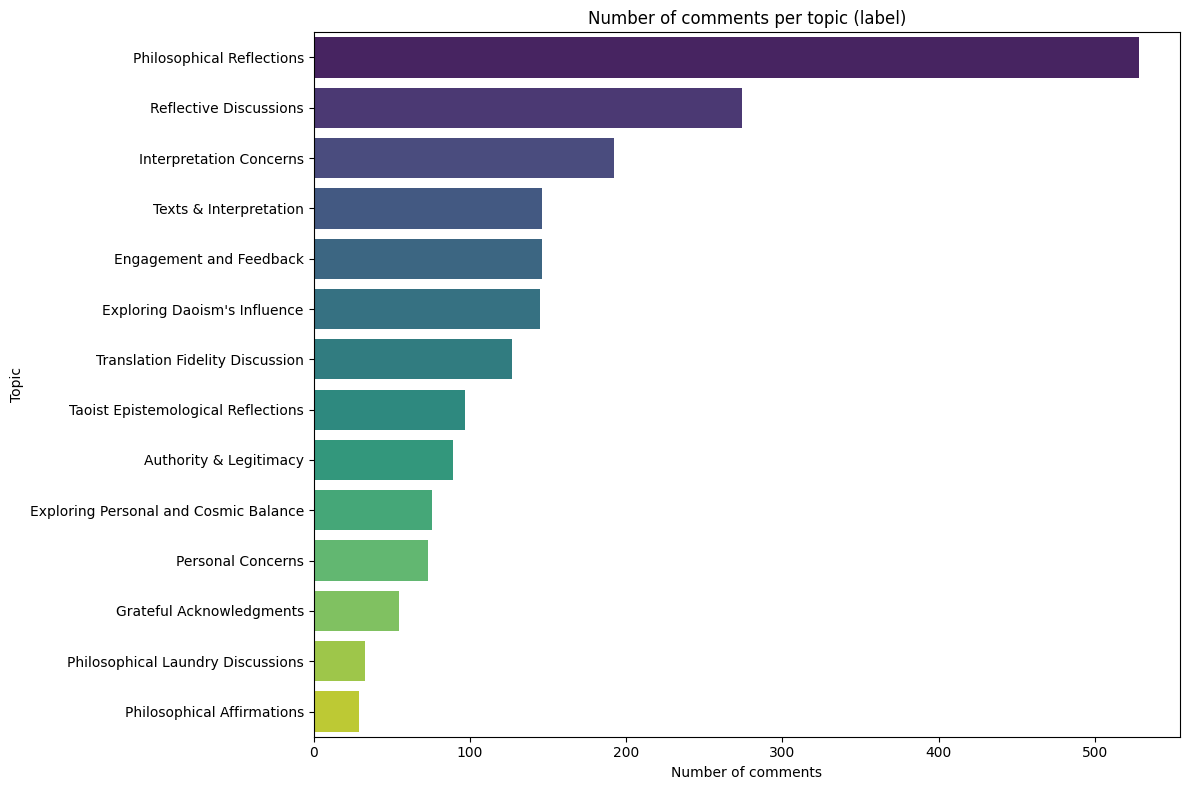

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

topic_counts = comments_df["combined_topic"].value_counts().reset_index()
topic_counts.columns = ["combined_topic", "count"]

plt.figure(figsize=(12, 8))
sns.barplot(data=topic_counts, y="combined_topic", x="count", hue="combined_topic", legend=False, palette="viridis")
plt.title("Number of comments per topic (label)")
plt.xlabel("Number of comments")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()


In [47]:
!pip install openai

In [49]:
from openai import OpenAI
from dotenv import load_dotenv
import os

In [71]:
import openai
from openai import OpenAI
from dotenv import load_dotenv
import os

# Load API key from .env file
load_dotenv()
openai.api_key = os.getenv("OPENAI_API_KEY")


# Initialize GPT-4 client
client = OpenAI()

# Dictionary to store mappings
rhetoric_mappings = {}

# Define the rhetoric categories
rhetoric_intro = """
You are assisting in an academic research project about digital religion. Based on the topic label and representative Reddit comments below, assign the most appropriate category from the following five rhetorical frames (Campbell & Teusner 2012):

1. Identity – exploring, experimenting with, or asserting personal beliefs or spiritual identity.
2. Community – creating a sense of belonging, mutual care, or shared language/practice online.
3. Network – displaying distributed identity, links to multiple communities, or decentralization.
4. Authority – discussing legitimacy, knowledge, power, or challenging religious control.
5. Blurring Online/Offline – showing how digital participation connects to offline practices or experiences.

Only choose one category. After the label, write a short explanation (2–3 sentences) about why this topic fits the chosen rhetoric.
"""

# Loop through each topic and send to GPT
for label in comments_df["combined_topic"].unique():
    sample = comments_df[comments_df["combined_topic"] == label]["body"].sample(6, random_state=42).tolist()
    
    # Construct the full prompt
    prompt = f"""{rhetoric_intro}

Topic label: "{label}"

Example comments:
1. {sample[0]}
2. {sample[1]}
3. {sample[2]}
4. {sample[3]}
5. {sample[4]}
6. {sample[5]}

What is the most appropriate rhetoric category and why?
"""
    
    # Send to GPT-4
    try:
        response = client.chat.completions.create(
            model="gpt-4-turbo",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.4
        )

        result = response.choices[0].message.content.strip()
        rhetoric_mappings[label] = result
        time.sleep(1)  # To avoid rate limits
    except Exception as e:
        print(f"Error for topic {label}: {e}")


In [73]:
import re

# Flexible matching of rhetoric in GPT response
rhetoric_labels_cleaned = {}

# Define valid categories in a list
valid_rhetorics = [
    "Identity",
    "Community",
    "Network",
    "Authority",
    "Blurring Online/Offline"
]

# Go through each GPT response
for topic, response in rhetoric_mappings.items():
    found = None
    for r in valid_rhetorics:
        if re.search(rf"\b{re.escape(r)}\b", response, re.IGNORECASE):
            found = r
            break
    rhetoric_labels_cleaned[topic] = found if found else "Unclear"


In [75]:
# Display GPT-4 outputs for manual inspection
for topic, response in rhetoric_mappings.items():
    print(f"\n=== Topic: {topic} ===")
    print(response)



=== Topic: Philosophical Reflections ===
Category: 1. Identity

Explanation: The comments under the topic "Philosophical Reflections" primarily explore and articulate personal beliefs and understandings of spiritual concepts such as the Tao, the nature of time, and individual perceptions of reality. Each comment reflects a personal interpretation or internalization of philosophical and spiritual ideas, highlighting the individual's journey in understanding and relating to these concepts. The discussions are introspective and focus on the personal implications of these beliefs, which aligns closely with the Identity rhetorical frame, where individuals are exploring or asserting their spiritual identity and beliefs.

=== Topic: Interpretation Concerns ===
**Category: Authority**

The comments under the topic "Interpretation Concerns" primarily focus on discussing the legitimacy and authenticity of Taoist teachings and practices. Commenters are actively challenging what they perceive as 

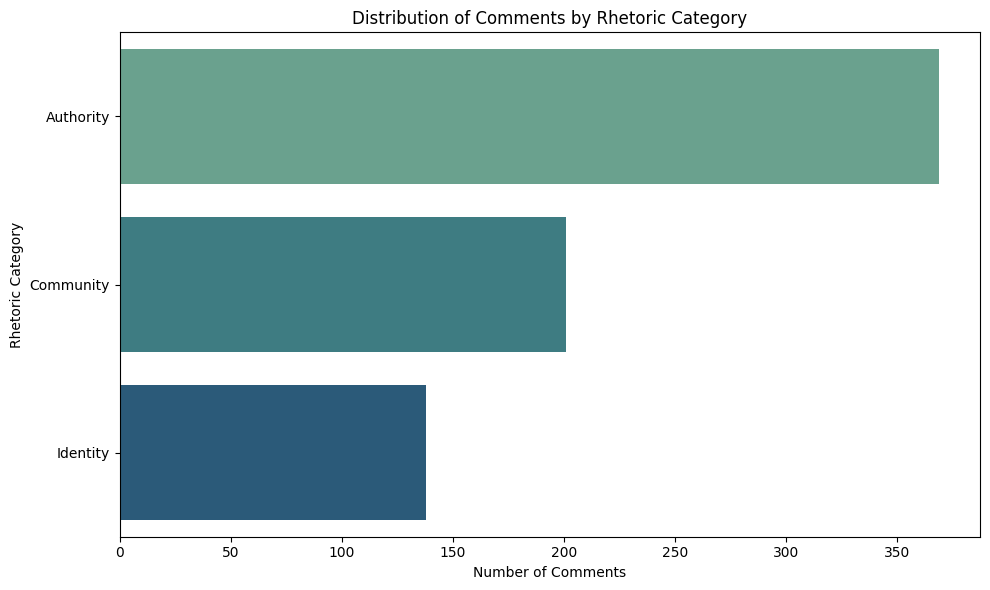

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map the cleaned rhetoric labels to each comment
comments_df["rhetoric"] = comments_df["topic_label"].map(rhetoric_labels_cleaned)

# Count the number of comments per rhetoric category
rhetoric_counts = comments_df["rhetoric"].value_counts().reset_index()
rhetoric_counts.columns = ["rhetoric", "count"]

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.barplot(data=rhetoric_counts, x="count", y="rhetoric", hue="rhetoric", legend=False, palette="crest")
plt.title("Distribution of Comments by Rhetoric Category")
plt.xlabel("Number of Comments")
plt.ylabel("Rhetoric Category")
plt.tight_layout()
plt.show()

In [79]:
for label in topic_counts["combined_label"]:
    print(f"\n--- {label} ---")
    sample = comments_df[comments_df["combined_label"] == label]["body"].sample(2, random_state=42).tolist()
    for comment in sample:
        print(f"• {comment[:200]}...\n")

KeyError: 'combined_label'